# Bitcoin News and Price Analysis with APIs

This notebook demonstrates how to use the NewsAPI and CoinGecko API via utility functions from TextBlob1_Utils.py to:
1. Fetch Bitcoin-related news articles
2. Retrieve current and historical Bitcoin price data
3. Perform basic correlation analysis between news coverage and price movements

## Setup and Imports

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import time
import json

# Import the utility functions
import TextBlob1_Utils as utils

# Create necessary directories
os.makedirs('data', exist_ok=True)

✅ Successfully imported enhanced Granger causality functions


## Part 1: Working with NewsAPI

The NewsAPI allows us to fetch news articles related to Bitcoin and cryptocurrency. We'll explore different ways to create search queries and fetch articles.

### 1.1 Creating Custom Search Queries

In [2]:
print("=" * 80)
print("📰 NEWSAPI DEMONSTRATION")
print("=" * 80)

# Simple Bitcoin query
btc_query = utils.create_query(include_bitcoin=True, include_crypto=False)
print(f"Bitcoin only query: {btc_query}")

# Bitcoin and crypto query (default)
default_query = utils.create_query()
print(f"Default query (Bitcoin + crypto): {default_query}")

# Custom keywords with Bitcoin
custom_query1 = utils.create_query(keywords=['etf', 'regulation', 'investment'], include_bitcoin=True)
print(f"Custom query with Bitcoin: {custom_query1}")

# Crypto only without Bitcoin
crypto_query = utils.create_query(include_bitcoin=False, include_crypto=True)
print(f"Crypto only query: {crypto_query}")

# Custom keywords only
custom_query2 = utils.create_query(keywords=['blockchain', 'defi', 'nft'], include_bitcoin=False, include_crypto=False)
print(f"Custom keywords only query: {custom_query2}")

📰 NEWSAPI DEMONSTRATION
Bitcoin only query: bitcoin OR btc
Default query (Bitcoin + crypto): bitcoin OR btc OR cryptocurrency OR crypto OR blockchain
Custom query with Bitcoin: bitcoin OR btc OR cryptocurrency OR crypto OR blockchain OR (etf OR regulation OR investment)
Crypto only query: cryptocurrency OR crypto OR blockchain
Custom keywords only query: (blockchain OR defi OR nft)


### 1.2 Fetching Bitcoin News Articles

Now let's use the `fetch_bitcoin_news()` function to retrieve news articles about Bitcoin.

> **Note:** You need a valid NewsAPI key in your .env file or environment. Get a free key at: https://newsapi.org/

In [3]:
# Try fetching with default parameters
print("\n📰 Fetching news with default parameters (7 days)...")
default_news = utils.fetch_bitcoin_news()
if default_news is not None:
    print(f"✅ Successfully fetched {len(default_news)} articles")
    # Display sample titles
    print("\nSample article titles:")
    for title in default_news['title'].head(3).tolist():
        print(f"  • {title}")
    
    # Show dataframe columns
    print("\nAvailable data columns:")
    print(default_news.columns.tolist())
else:
    print("⚠️ Could not fetch news with default parameters")


📰 Fetching news with default parameters (7 days)...
💬 Using search query: 'bitcoin OR cryptocurrency'
📅 Fetching news for the past 7 days
  → Fetching articles for 2025-05-18...
    ✓ No articles found for 2025-05-18
  → Fetching articles for 2025-05-17...
    ✓ Found 22 articles
  → Fetching articles for 2025-05-16...
    ✓ Found 99 articles
  → Fetching articles for 2025-05-15...
    ✓ Found 100 articles
  → Fetching articles for 2025-05-14...
    ✓ Found 99 articles
  → Fetching articles for 2025-05-13...
    ✓ Found 99 articles
  → Fetching articles for 2025-05-12...
    ✓ Found 98 articles
📊 Removed 1 duplicate articles
✅ Successfully fetched 516 unique news articles over 7 days

💬 Sample article titles:
  • Don't be a victim! FBI warns iOS, Android users about the latest scam
  • Dogecoin Hovers at $0.22 Following Weeks of Gains, Analysts Share Mixed Outlooks
  • Elon Musk revives ‘Kekius Maximus’ persona, triggers new meme coin gold rush
  • Paraguay deports three undocumented 

In [4]:
# Try with custom parameters (fewer days to complete quickly)
print("\n📰 Fetching news with custom parameters (3 days, custom query)...")
custom_news = utils.fetch_bitcoin_news(
    days=3,
    query='bitcoin AND (etf OR investment)',
    language='en',
    sleep_between_days=0.2
)

if custom_news is not None:
    print(f"✅ Successfully fetched {len(custom_news)} articles with custom parameters")
    # Display data types and shapes
    print("\nData types and shapes:")
    for col in ['title', 'description', 'publishedAt', 'source', 'url']:
        if col in custom_news.columns:
            print(f"  • {col}: {type(custom_news[col].iloc[0]).__name__}")
            
    # Show distribution of articles by date
    if 'date' in custom_news.columns:
        article_counts = custom_news.groupby('date').size()
        print("\nArticles per day:")
        print(article_counts)
else:
    print("⚠️ Could not fetch news with custom parameters")


📰 Fetching news with custom parameters (3 days, custom query)...
💬 Using search query: 'bitcoin AND (etf OR investment)'
📅 Fetching news for the past 3 days
  → Fetching articles for 2025-05-18...
    ✓ No articles found for 2025-05-18
  → Fetching articles for 2025-05-17...
    ✓ Found 6 articles
  → Fetching articles for 2025-05-16...
    ✓ Found 100 articles
📊 Removed 6 duplicate articles
✅ Successfully fetched 100 unique news articles over 3 days

💬 Sample article titles:
  • Ripple BTC and XRP investors use CRYPTO MINING FIRM's cloud mining skills to earn high profits every day, or they can experience cloud mining for free and make money.
  • ALL4 Mining: Best Free Bitcoin Litecoin and Dogecoin Cloud Mining Platform Regulated in the UK
  • Man gets 14 months in jail for role in SEC’s X account hack that pumped fake Bitcoin ETF hype
  • Bitcoin stalls near record highs amid derivative pressures but breakout potential remains
  • Bitcoin bull flag and standard profit taking hint at

## Part 2: Working with CoinGecko API

The CoinGecko API provides cryptocurrency market data. We'll use it to fetch Bitcoin's current price and historical price data.

### 2.1 Fetching Current Bitcoin Price

In [5]:
print("\n" + "=" * 80)
print("💰 COINGECKO API DEMONSTRATION")
print("=" * 80)

# Note about API
print("Note: CoinGecko API is free but has rate limits")
print("This code includes automatic handling of rate limits")

# Fetch current price
current_price = utils.fetch_current_bitcoin_price()
if current_price:
    print(f"✅ Current Bitcoin price: ${current_price['price']:,.2f}")
    
    # Display all available data
    print("\nAvailable data from current price API:")
    for key, value in current_price.items():
        if key != 'timestamp':  # Skip timestamp for cleaner output
            if isinstance(value, (int, float)):
                print(f"  • {key}: {value:,.2f}")
            else:
                print(f"  • {key}: {value}")
else:
    print("⚠️ Could not fetch current Bitcoin price")


💰 COINGECKO API DEMONSTRATION
Note: CoinGecko API is free but has rate limits
This code includes automatic handling of rate limits
  → Cached price data expired (5 min), fetching fresh data...
  → Fetching current Bitcoin price...
  ✓ Current Bitcoin price: $103,271.00
✅ Current Bitcoin price: $103,271.00

Available data from current price API:
  • price: 103,271.00
  • market_cap: 2,051,773,135,063.03
  • vol_24h: 17,155,025,616.58
  • change_24h: 0.05


### 2.2 Fetching Historical Bitcoin Prices

Next, we'll fetch historical Bitcoin price data and visualize it.


💰 Fetching with default parameters (30 days, daily)...
  ✓ Using cached price data (from 2025-05-18 03:26:19)
  ✓ Using cached price data (last updated: 2025-05-18 00:00:00)
✅ Successfully fetched 31 price data points

Sample price data:
    timestamp         price       date  hour
0  2025-04-18  84619.822969 2025-04-18     0
1  2025-04-19  85071.920423 2025-04-19     0
2  2025-04-20  84760.039451 2025-04-20     0


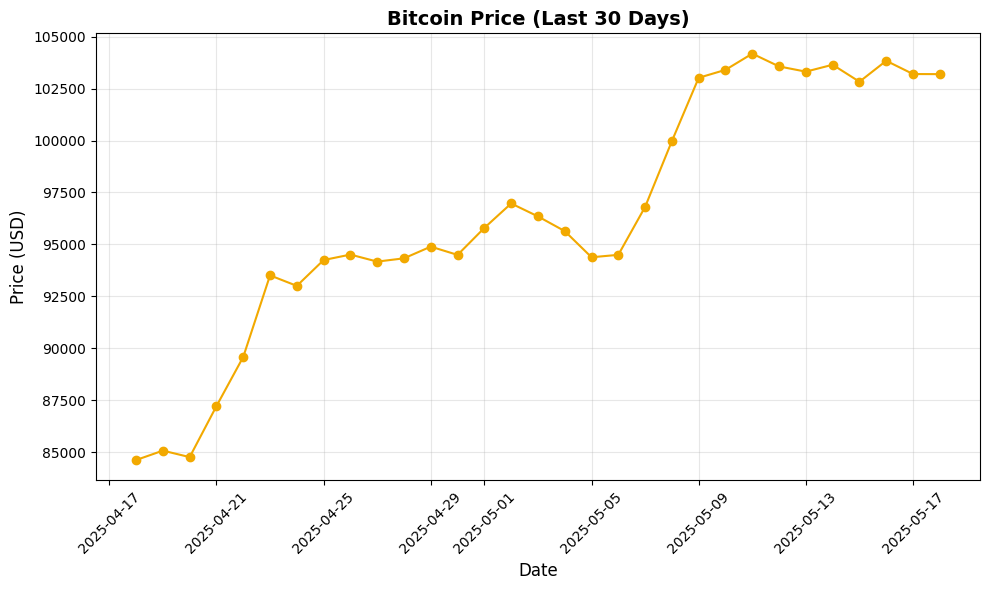

In [6]:
# Fetch with default parameters (30 days, daily interval)
print("\n💰 Fetching with default parameters (30 days, daily)...")
default_prices = utils.fetch_bitcoin_prices()
if default_prices is not None:
    print(f"✅ Successfully fetched {len(default_prices)} price data points")
    
    # Show sample data
    print("\nSample price data:")
    print(default_prices.head(3))
    
    # Convert timestamp to date only (removing time)
    default_prices['date_only'] = pd.to_datetime(default_prices['timestamp']).dt.date
    
    # Plot the price data using date_only
    plt.figure(figsize=(10, 6))
    plt.plot(default_prices['date_only'], default_prices['price'], 'o-', color='#f2a900')
    plt.title('Bitcoin Price (Last 30 Days)', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price (USD)', fontsize=12)
    plt.grid(alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Could not fetch historical prices with default parameters")

In [7]:
# Fetch with custom parameters (7 days, hourly interval if available)
print("\n💰 Fetching with custom parameters (7 days, hourly)...")
custom_prices = utils.fetch_bitcoin_prices(days=7, interval='hourly')
if custom_prices is not None:
    print(f"✅ Successfully fetched {len(custom_prices)} price data points with custom parameters")
    
    # Check if we actually got hourly data
    hourly_count = len(custom_prices['hour'].unique())
    if hourly_count > 1:
        print(f"  ℹ️ Data contains {hourly_count} unique hours (hourly data)")
    else:
        print(f"  ℹ️ Data contains only one hour value (daily data)")
    
    # Calculate statistics
    min_price = custom_prices['price'].min()
    max_price = custom_prices['price'].max()
    avg_price = custom_prices['price'].mean()
    volatility = custom_prices['price'].std() / avg_price * 100  # % volatility
    
    print(f"\nBitcoin price statistics (last 7 days):")
    print(f"  • Minimum: ${min_price:,.2f}")
    print(f"  • Maximum: ${max_price:,.2f}")
    print(f"  • Average: ${avg_price:,.2f}")
    print(f"  • Volatility: {volatility:.2f}%")
else:
    print("⚠️ Could not fetch historical prices with custom parameters")


💰 Fetching with custom parameters (7 days, hourly)...
  ✓ Using cached price data (from 2025-05-18 03:26:19)
  ✓ Using cached price data (last updated: 2025-05-18 00:00:00)
✅ Successfully fetched 31 price data points with custom parameters
  ℹ️ Data contains only one hour value (daily data)

Bitcoin price statistics (last 7 days):
  • Minimum: $84,619.82
  • Maximum: $104,180.87
  • Average: $96,419.12
  • Volatility: 6.26%


## Summary

In this notebook, we've demonstrated:

1. **NewsAPI Usage**:
   - Creating custom search queries
   - Fetching news articles with various parameters

2. **CoinGecko API Usage**:
   - Retrieving current Bitcoin price information
   - Fetching and visualizing historical price data


This provides a foundation for more advanced analyses, such as:
- Sentiment analysis of news articles using TextBlob
- Time-lagged correlation analysis
- Granger causality testing between news sentiment and price movements